regresion multiple

importacionde librerias 

In [6]:
# Manejo de directorios y rutas
import os

# Computación numérica y manejo de matrices
import numpy as np

# Manejo y preprocesamiento de datos
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot

# Mostrar gráficos dentro del cuadernillo
%matplotlib inline

conoceremos un poco mas el dataset

In [7]:
# Cargar el dataset
datos = pd.read_csv("dataset/diabetes_dataset.csv")

# Mostrar dimensiones
print("Número de ejemplos:", datos.shape[0])
print("Número de características/columnas:", datos.shape[1])

# Mostrar nombres de las columnas
print("\nColumnas del dataset:")
print(datos.columns.tolist())

# Mostrar las primeras filas
datos.head()

Número de ejemplos: 100000
Número de características/columnas: 31

Columnas del dataset:
['age', 'gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score', 'diabetes_stage', 'diagnosed_diabetes']


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [4]:
print(datos.dtypes)

age                                     int64
gender                                    str
ethnicity                                 str
education_level                           str
income_level                              str
employment_status                         str
smoking_status                            str
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
family_history_diabetes                 int64
hypertension_history                    int64
cardiovascular_history                  int64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate                              int64
cholesterol_total                       int64
hdl_cholesterol                   

In [17]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  str    
 2   ethnicity                           100000 non-null  str    
 3   education_level                     100000 non-null  str    
 4   income_level                        100000 non-null  str    
 5   employment_status                   100000 non-null  str    
 6   smoking_status                      100000 non-null  str    
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day           10

In [10]:
columnas_texto = datos.select_dtypes(include="str").columns

for columna in columnas_texto:
    print("\n" + "=" * 50)
    print(columna)
    print("=" * 50)
    print(datos[columna].value_counts())


gender
gender
Female    50216
Male      47771
Other      2013
Name: count, dtype: int64

ethnicity
ethnicity
White       44997
Hispanic    20103
Black       17986
Asian       11865
Other        5049
Name: count, dtype: int64

education_level
education_level
Highschool      44891
Graduate        35037
Postgraduate    14972
No formal        5100
Name: count, dtype: int64

income_level
income_level
Middle          35152
Lower-Middle    25150
Upper-Middle    19866
Low             14830
High             5002
Name: count, dtype: int64

employment_status
employment_status
Employed      60175
Retired       21761
Unemployed    11918
Student        6146
Name: count, dtype: int64

smoking_status
smoking_status
Never      59813
Current    20176
Former     20011
Name: count, dtype: int64

diabetes_stage
diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Gestational       278
Type 1            122
Name: count, dtype: int64


In [12]:
# Crear una copia del dataset original
datos_modelo = datos.copy()

print("Dataset original:", datos.shape)
print("Copia para el modelo:", datos_modelo.shape)

Dataset original: (100000, 31)
Copia para el modelo: (100000, 31)


In [13]:
# Eliminar la variable que no utilizaremos
datos_modelo = datos_modelo.drop(columns=["diabetes_stage"])

In [14]:
print("Copia para el modelo:", datos_modelo.shape)

Copia para el modelo: (100000, 30)


ahora hemos crado una copia del dataset la cual alterraremos para mejorrarlo, quitamos una columna que podia hacer que el modelo aprenda unicamente por esa columna haciendo que las otras no tengan valor, ahora a su ves conocemos que el dataset contiene 6 columnas de tipo texto que usaremos, aplicaremos un metodo One-Hot Encoding, partiremos la columna de texto en los valores que contiene, haciendo que cada tipo de valor se subdidiva en otra columna tomando el valor binario para cada m

ahora paticionaremos las columnas de texto

In [15]:
# Variables categóricas que vamos a transformar
columnas_categoricas = [
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status"
]

# Convertir variables categóricas a variables numéricas
datos_modelo = pd.get_dummies(
    datos_modelo,
    columns=columnas_categoricas,
    dtype=int
)

In [16]:
print("Copia para el modelo:", datos_modelo.shape)

Copia para el modelo: (100000, 48)


In [18]:
datos_modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   alcohol_consumption_per_week        100000 non-null  int64  
 2   physical_activity_minutes_per_week  100000 non-null  int64  
 3   diet_score                          100000 non-null  float64
 4   sleep_hours_per_day                 100000 non-null  float64
 5   screen_time_hours_per_day           100000 non-null  float64
 6   family_history_diabetes             100000 non-null  int64  
 7   hypertension_history                100000 non-null  int64  
 8   cardiovascular_history              100000 non-null  int64  
 9   bmi                                 100000 non-null  float64
 10  waist_to_hip_ratio                  100000 non-null  float64
 11  systolic_bp                         10

comenzamos con la construccion del modelo:

creamos variables

In [19]:
# Separar las características (X) de la variable objetivo (y)
X = datos_modelo.drop(columns=["diagnosed_diabetes"])
y = datos_modelo["diagnosed_diabetes"]

print("Número de ejemplos:", X.shape[0])
print("Número de características:", X.shape[1])
print("Variable objetivo:", y.name)

Número de ejemplos: 100000
Número de características: 47
Variable objetivo: diagnosed_diabetes


In [20]:
X = X.to_numpy()
y = y.to_numpy()

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (100000, 47)
Forma de y: (100000,)


normalizaremos los datos

In [21]:
def featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [22]:
# Normalizar las características
X_norm, mu, sigma = featureNormalize(X)

print("Forma de X:", X.shape)
print("Forma de X_norm:", X_norm.shape)

print("\nMedia calculada:")
print(mu)

print("\nDesviación estándar calculada:")
print(sigma)

print("\nPrimeras 5 filas de X_norm:")
print(X_norm[:5])

Forma de X: (100000, 47)
Forma de X_norm: (100000, 47)

Media calculada:
[5.0120410e+01 2.0036700e+00 1.1891164e+02 5.9947870e+00 6.9978180e+00
 5.9964680e+00 2.1941000e-01 2.5080000e-01 7.9200000e-02 2.5612653e+01
 8.5607800e-01 1.1579961e+02 7.5232490e+01 6.9632870e+01 1.8597811e+02
 5.4042790e+01 1.0300043e+02 1.2146265e+02 1.1111712e+02 1.6003505e+02
 9.0612424e+00 6.5207762e+00 3.0222362e+01 5.0216000e-01 4.7771000e-01
 2.0130000e-02 1.1865000e-01 1.7986000e-01 2.0103000e-01 5.0490000e-02
 4.4997000e-01 3.5037000e-01 4.4891000e-01 5.1000000e-02 1.4972000e-01
 5.0020000e-02 1.4830000e-01 2.5150000e-01 3.5152000e-01 1.9866000e-01
 6.0175000e-01 2.1761000e-01 6.1460000e-02 1.1918000e-01 2.0176000e-01
 2.0011000e-01 5.9813000e-01]

Desviación estándar calculada:
[1.56045215e+01 1.41777168e+00 8.44092404e+01 1.78094540e+00
 1.09461694e+00 2.46839371e+00 4.13846894e-01 4.33473598e-01
 2.70050662e-01 3.58668680e+00 4.68370357e-02 1.42840013e+01
 8.20420858e+00 8.37191170e+00 3.20128454e+

numero de ejemplo

In [23]:
# Número de ejemplos
m = y.size

print("Número de ejemplos:", m)

Número de ejemplos: 100000


agregamos la columa de 1

In [24]:
# Agregar una columna de unos para el término independiente θ0
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print("Forma final de X:", X.shape)

Forma final de X: (100000, 48)


funcion de costo

In [25]:
def computeCostMulti(X, y, theta):
    # Número de ejemplos de entrenamiento
    m = y.shape[0]

    # Calcular el costo
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

descenso por gradiente

In [26]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    m = y.shape[0]

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

coheficientes de aprendizaje

In [39]:
# Tasa de aprendizaje
alpha = 0.03

# Número de iteraciones
num_iters = 10000

# Inicializar theta con un valor por cada columna de X
theta = np.zeros(X.shape[1])

# Ejecutar el descenso por gradiente
theta, J_history = gradientDescentMulti(
    X,
    y,
    theta,
    alpha,
    num_iters
)

print("Número de parámetros:", len(theta))
print("Costo inicial:", J_history[0])
print("Costo final:", J_history[-1])

Número de parámetros: 48
Costo inicial: 0.2803574307396904
Costo final: 0.0640823959018176


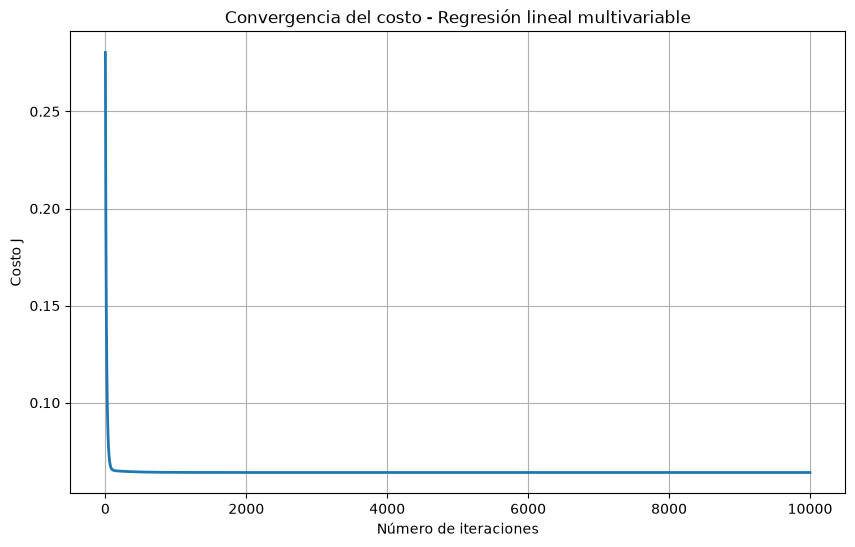

In [40]:
pyplot.figure(figsize=(10, 6))

pyplot.plot(
    np.arange(len(J_history)),
    J_history,
    lw=2
)

pyplot.xlabel("Número de iteraciones")
pyplot.ylabel("Costo J")
pyplot.title("Convergencia del costo - Regresión lineal multivariable")

pyplot.grid()
pyplot.show()

iteraccion:

In [41]:
# Elegir un ejemplo del dataset
indice = 0

# Obtener sus características
x_ejemplo = X[indice]

# Obtener el valor real
y_real = y[indice]

# Realizar la predicción
y_predicha = np.dot(x_ejemplo, theta)

print("Ejemplo:", indice)
print("Y real:      ", y_real)
print("Y predicha:  ", y_predicha)

Ejemplo: 0
Y real:       1
Y predicha:   1.2802954131395266


In [42]:
print("Costo inicial:", J_history[0])
print("Costo final:", J_history[-1])

Costo inicial: 0.2803574307396904
Costo final: 0.0640823959018176


In [43]:
# Realizar predicciones para los primeros 10 ejemplos

for i in range(10):
    y_predicha = np.dot(X[i], theta)
    
    print(
        f"Ejemplo {i:2d} | "
        f"Y real: {y[i]} | "
        f"Y predicha: {y_predicha:.4f}"
    )

Ejemplo  0 | Y real: 1 | Y predicha: 1.2803
Ejemplo  1 | Y real: 0 | Y predicha: 0.2108
Ejemplo  2 | Y real: 1 | Y predicha: 1.0172
Ejemplo  3 | Y real: 1 | Y predicha: 1.6209
Ejemplo  4 | Y real: 1 | Y predicha: 0.8818
Ejemplo  5 | Y real: 0 | Y predicha: 0.3791
Ejemplo  6 | Y real: 0 | Y predicha: 0.1170
Ejemplo  7 | Y real: 1 | Y predicha: 0.8057
Ejemplo  8 | Y real: 1 | Y predicha: 0.7506
Ejemplo  9 | Y real: 0 | Y predicha: -0.0431


In [44]:
# Número de predicciones que queremos realizar
num_predicciones = 100

# Contador de predicciones correctas
aciertos = 0

print("RESULTADOS DE LAS 100 PREDICCIONES")
print("=" * 60)

for i in range(num_predicciones):

    # Predicción continua del modelo
    y_predicha = np.dot(X[i], theta)

    # Convertir la predicción a 0 o 1
    if y_predicha >= 0.5:
        y_clasificada = 1
    else:
        y_clasificada = 0

    # Comprobar si acertó
    if y_clasificada == y[i]:
        aciertos += 1

    print(
        f"Ejemplo {i+1:3d} | "
        f"Y real: {y[i]} | "
        f"Y predicha: {y_predicha:.4f} | "
        f"Clasificación: {y_clasificada}"
    )

# Calcular porcentaje de aciertos
porcentaje = (aciertos / num_predicciones) * 100

print("=" * 60)
print("Predicciones realizadas:", num_predicciones)
print("Predicciones correctas:", aciertos)
print(f"Porcentaje de aciertos: {porcentaje:.2f}%")

RESULTADOS DE LAS 100 PREDICCIONES
Ejemplo   1 | Y real: 1 | Y predicha: 1.2803 | Clasificación: 1
Ejemplo   2 | Y real: 0 | Y predicha: 0.2108 | Clasificación: 0
Ejemplo   3 | Y real: 1 | Y predicha: 1.0172 | Clasificación: 1
Ejemplo   4 | Y real: 1 | Y predicha: 1.6209 | Clasificación: 1
Ejemplo   5 | Y real: 1 | Y predicha: 0.8818 | Clasificación: 1
Ejemplo   6 | Y real: 0 | Y predicha: 0.3791 | Clasificación: 0
Ejemplo   7 | Y real: 0 | Y predicha: 0.1170 | Clasificación: 0
Ejemplo   8 | Y real: 1 | Y predicha: 0.8057 | Clasificación: 1
Ejemplo   9 | Y real: 1 | Y predicha: 0.7506 | Clasificación: 1
Ejemplo  10 | Y real: 0 | Y predicha: -0.0431 | Clasificación: 0
Ejemplo  11 | Y real: 1 | Y predicha: 0.9193 | Clasificación: 1
Ejemplo  12 | Y real: 1 | Y predicha: 0.9078 | Clasificación: 1
Ejemplo  13 | Y real: 1 | Y predicha: 0.7785 | Clasificación: 1
Ejemplo  14 | Y real: 0 | Y predicha: 0.1241 | Clasificación: 0
Ejemplo  15 | Y real: 0 | Y predicha: 0.3293 | Clasificación: 0
Ejem

ecuacion de la normal

In [46]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(
        np.dot(
            np.linalg.inv(np.dot(X.T, X)),
            X.T
        ),
        y
    )

    return theta

llamamos a la ecuacion

In [47]:
theta_normal = normalEqn(X, y)

print("Número de parámetros:", len(theta_normal))
print("Theta calculado mediante la ecuación de la normal:")
print(theta_normal)

Número de parámetros: 48
Theta calculado mediante la ecuación de la normal:
[ 5.99980000e-01  1.25949206e-02 -1.94428303e-03 -1.07759596e-02
 -1.95715976e-03 -7.15480895e-04  8.84581305e-04  1.54981032e-02
 -2.57085037e-05  1.62588392e-03  5.21255759e-03  2.43001269e-03
  4.28337175e-04 -1.60228077e-03 -8.92740410e-05 -2.07230830e-03
 -1.94122528e-03  3.59740860e-03  1.87275177e-03  2.32114588e-02
  1.34121720e-03 -9.11201508e-04  3.07699111e-01 -1.81743721e-03
 -2.28716310e-02 -2.21002499e-02 -4.30694143e-03  2.03508682e-02
  6.72205592e-02  7.63635455e-02  3.74441031e-02  9.38474220e-02
 -5.52381084e-02 -4.09355999e-02 -3.08217129e-02 -5.01445248e-02
  3.31211841e-02  4.84628971e-02  5.63378372e-02  6.36051925e-02
  4.59302194e-02 -5.75687541e-02 -4.64294823e-02 -2.50742659e-02
 -3.00596513e-02  6.50174883e-02  6.23050312e-02  7.16730170e-02]


In [48]:
# Número de predicciones que queremos realizar
num_predicciones = 100

# Contador de predicciones correctas
aciertos = 0

print("RESULTADOS DE LAS 100 PREDICCIONES - ECUACIÓN DE LA NORMAL")
print("=" * 70)

for i in range(num_predicciones):

    # Predicción continua utilizando theta obtenido por la ecuación de la normal
    y_predicha = np.dot(X[i], theta_normal)

    # Convertir la predicción a 0 o 1
    if y_predicha >= 0.5:
        y_clasificada = 1
    else:
        y_clasificada = 0

    # Comprobar si acertó
    if y_clasificada == y[i]:
        aciertos += 1

    print(
        f"Ejemplo {i+1:3d} | "
        f"Y real: {y[i]} | "
        f"Y predicha: {y_predicha:.4f} | "
        f"Clasificación: {y_clasificada}"
    )

# Calcular porcentaje de aciertos
porcentaje = (aciertos / num_predicciones) * 100

print("=" * 70)
print("Predicciones realizadas:", num_predicciones)
print("Predicciones correctas:", aciertos)
print(f"Porcentaje de aciertos: {porcentaje:.2f}%")

RESULTADOS DE LAS 100 PREDICCIONES - ECUACIÓN DE LA NORMAL
Ejemplo   1 | Y real: 1 | Y predicha: 1.1830 | Clasificación: 1
Ejemplo   2 | Y real: 0 | Y predicha: 0.2543 | Clasificación: 0
Ejemplo   3 | Y real: 1 | Y predicha: 1.0758 | Clasificación: 1
Ejemplo   4 | Y real: 1 | Y predicha: 1.6519 | Clasificación: 1
Ejemplo   5 | Y real: 1 | Y predicha: 0.8912 | Clasificación: 1
Ejemplo   6 | Y real: 0 | Y predicha: 0.3949 | Clasificación: 0
Ejemplo   7 | Y real: 0 | Y predicha: 0.1068 | Clasificación: 0
Ejemplo   8 | Y real: 1 | Y predicha: 0.8290 | Clasificación: 1
Ejemplo   9 | Y real: 1 | Y predicha: 0.7834 | Clasificación: 1
Ejemplo  10 | Y real: 0 | Y predicha: -0.0260 | Clasificación: 0
Ejemplo  11 | Y real: 1 | Y predicha: 0.9537 | Clasificación: 1
Ejemplo  12 | Y real: 1 | Y predicha: 0.9515 | Clasificación: 1
Ejemplo  13 | Y real: 1 | Y predicha: 0.8125 | Clasificación: 1
Ejemplo  14 | Y real: 0 | Y predicha: 0.1287 | Clasificación: 0
Ejemplo  15 | Y real: 0 | Y predicha: 0.2319

regresion polinomial

nueva copia del dataset

In [50]:
# Cargar una nueva copia del dataset
df_poly = pd.read_csv("dataset/diabetes_dataset.csv")

print("Filas:", df_poly.shape[0])
print("Columnas:", df_poly.shape[1])

Filas: 100000
Columnas: 31


In [51]:
print(df_poly.head())
print("\nForma del dataset:", df_poly.shape)

   age  gender ethnicity education_level  income_level employment_status  \
0   58    Male     Asian      Highschool  Lower-Middle          Employed   
1   48  Female     White      Highschool        Middle          Employed   
2   60    Male  Hispanic      Highschool        Middle        Unemployed   
3   74  Female     Black      Highschool           Low           Retired   
4   46    Male     White        Graduate        Middle           Retired   

  smoking_status  alcohol_consumption_per_week  \
0          Never                             0   
1         Former                             1   
2          Never                             1   
3          Never                             0   
4          Never                             1   

   physical_activity_minutes_per_week  diet_score  ...  hdl_cholesterol  \
0                                 215         5.7  ...               41   
1                                 143         6.7  ...               55   
2                

In [52]:
# Eliminar la variable que no utilizaremos
df_poly = df_poly.drop(columns=["diabetes_stage"])

In [53]:
print("Forma del dataset:", df_poly.shape)

Forma del dataset: (100000, 30)


In [54]:
# Variables categóricas que vamos a transformar
columnas_categoricas = [
    "gender",
    "ethnicity",
    "education_level",
    "income_level",
    "employment_status",
    "smoking_status"
]

# Convertir variables categóricas a variables numéricas
df_poly = pd.get_dummies(
    df_poly,
    columns=columnas_categoricas,
    dtype=int
)

In [55]:
print("Forma del dataset:", df_poly.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   alcohol_consumption_per_week        100000 non-null  int64  
 2   physical_activity_minutes_per_week  100000 non-null  int64  
 3   diet_score                          100000 non-null  float64
 4   sleep_hours_per_day                 100000 non-null  float64
 5   screen_time_hours_per_day           100000 non-null  float64
 6   family_history_diabetes             100000 non-null  int64  
 7   hypertension_history                100000 non-null  int64  
 8   cardiovascular_history              100000 non-null  int64  
 9   bmi                                 100000 non-null  float64
 10  waist_to_hip_ratio                  100000 non-null  float64
 11  systolic_bp                         10

cargaremos los datos a las nuevas variables para la egrecion polinomial

In [56]:
# Separar las características de la variable objetivo

X_poly = df_poly.drop(columns=["diagnosed_diabetes"])
y_poly = df_poly["diagnosed_diabetes"]

# Número de ejemplos de entrenamiento
m_poly = y_poly.size

print("Número de ejemplos:", m_poly)
print("Forma de X_poly:", X_poly.shape)
print("Forma de y_poly:", y_poly.shape)

Número de ejemplos: 100000
Forma de X_poly: (100000, 47)
Forma de y_poly: (100000,)


In [57]:
X_poly = X_poly.to_numpy()
y_poly = y_poly.to_numpy()

print("Forma de X_poly:", X_poly.shape)
print("Forma de y_poly:", y_poly.shape)

Forma de X_poly: (100000, 47)
Forma de y_poly: (100000,)


caracteristicas polinomicas de grado2

In [58]:
# Crear características polinómicas de grado 2

X_poly = np.concatenate(
    [X_poly, X_poly ** 2],
    axis=1
)

print("Forma de X_poly:", X_poly.shape)

Forma de X_poly: (100000, 94)


normalizamos

In [59]:
# Normalizar las características polinómicas

X_poly_norm, mu_poly, sigma_poly = featureNormalize(X_poly)

print("Forma de X_poly:", X_poly.shape)
print("Forma de X_poly_norm:", X_poly_norm.shape)

print("\nPrimeras 5 filas normalizadas:")
print(X_poly_norm[:5])

Forma de X_poly: (100000, 94)
Forma de X_poly_norm: (100000, 94)

Primeras 5 filas normalizadas:
[[ 5.04955567e-01 -1.41325295e+00  1.13836305e+00 -1.65522761e-01
   8.24198831e-01  7.71162230e-01 -5.30171914e-01 -5.78581951e-01
  -2.93278304e-01  1.36263557e+00  7.24255911e-01  1.27418008e+00
   3.37328089e-01 -1.95041474e-01  1.65626920e+00 -1.27032043e+00
   1.70708052e+00  5.42680342e-01  1.83022346e+00  2.45560599e+00
  -5.45261091e-01  2.03856648e+00 -6.86823129e-02 -1.00432937e+00
   1.04561954e+00 -1.43330183e-01  2.72546327e+00 -4.68299072e-01
  -5.01608861e-01 -2.30596608e-01 -9.04479215e-01 -7.34396199e-01
   1.10797925e+00 -2.31820577e-01 -4.19622655e-01 -2.29464028e-01
  -4.17279695e-01  1.72515018e+00 -7.36252405e-01 -4.97905364e-01
   8.13523013e-01 -5.27385007e-01 -2.55899764e-01 -3.67839283e-01
  -5.02748509e-01 -5.00171869e-01  8.19681250e-01  3.76956185e-01
  -7.89382963e-01  7.72180964e-01 -3.07179586e-01  7.95318521e-01
   6.52414062e-01 -5.30171914e-01 -5.78581951

agregamos la columna de 1

In [60]:
# Añadir el término de intersección theta_0

X_poly = np.concatenate(
    [np.ones((m_poly, 1)), X_poly_norm],
    axis=1
)

print("Forma final de X_poly:", X_poly.shape)

Forma final de X_poly: (100000, 95)


coheficientes de aprendizaje

In [63]:
# Configuración del descenso por gradiente

alpha_poly = 0.03
num_iters_poly = 10000

# Inicializar theta
theta_poly = np.zeros(X_poly.shape[1])

# Entrenar el modelo polinómico
theta_poly, J_history_poly = gradientDescentMulti(
    X_poly,
    y_poly,
    theta_poly,
    alpha_poly,
    num_iters_poly
)

print("Número de parámetros:", len(theta_poly))
print("Costo inicial:", J_history_poly[0])
print("Costo final:", J_history_poly[-1])

Número de parámetros: 95
Costo inicial: 0.2724687829568206
Costo final: 0.06388826525085244


grafica de costo

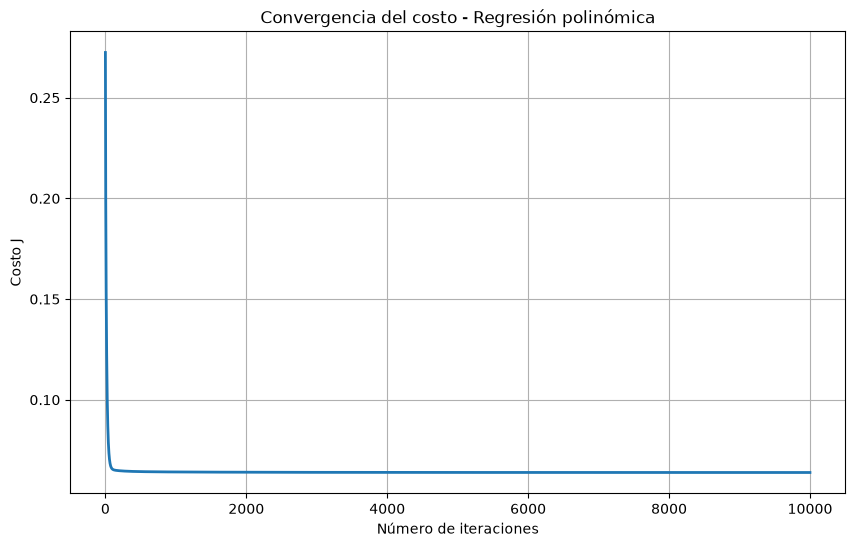

In [64]:
pyplot.figure(figsize=(10, 6))

pyplot.plot(
    np.arange(len(J_history_poly)),
    J_history_poly,
    lw=2
)

pyplot.xlabel("Número de iteraciones")
pyplot.ylabel("Costo J")
pyplot.title("Convergencia del costo - Regresión polinómica")

pyplot.grid()
pyplot.show()

100 inferencias

In [65]:
# Número de predicciones que queremos realizar
num_predicciones = 100

# Contador de predicciones correctas
aciertos = 0

print("RESULTADOS DE LAS 100 PREDICCIONES - REGRESIÓN POLINÓMICA")
print("=" * 70)

for i in range(num_predicciones):

    # Predicción utilizando los parámetros del modelo polinómico
    y_predicha = np.dot(X_poly[i], theta_poly)

    # Convertir la predicción a 0 o 1
    if y_predicha >= 0.5:
        y_clasificada = 1
    else:
        y_clasificada = 0

    # Comprobar si acertó
    if y_clasificada == y_poly[i]:
        aciertos += 1

    print(
        f"Ejemplo {i+1:3d} | "
        f"Y real: {y_poly[i]} | "
        f"Y predicha: {y_predicha:.4f} | "
        f"Clasificación: {y_clasificada}"
    )

# Calcular porcentaje de aciertos
porcentaje = (aciertos / num_predicciones) * 100

print("=" * 70)
print("Predicciones realizadas:", num_predicciones)
print("Predicciones correctas:", aciertos)
print(f"Porcentaje de aciertos: {porcentaje:.2f}%")

RESULTADOS DE LAS 100 PREDICCIONES - REGRESIÓN POLINÓMICA
Ejemplo   1 | Y real: 1 | Y predicha: 1.2296 | Clasificación: 1
Ejemplo   2 | Y real: 0 | Y predicha: 0.2254 | Clasificación: 0
Ejemplo   3 | Y real: 1 | Y predicha: 1.0173 | Clasificación: 1
Ejemplo   4 | Y real: 1 | Y predicha: 1.5204 | Clasificación: 1
Ejemplo   5 | Y real: 1 | Y predicha: 0.8832 | Clasificación: 1
Ejemplo   6 | Y real: 0 | Y predicha: 0.3842 | Clasificación: 0
Ejemplo   7 | Y real: 0 | Y predicha: 0.0894 | Clasificación: 0
Ejemplo   8 | Y real: 1 | Y predicha: 0.8083 | Clasificación: 1
Ejemplo   9 | Y real: 1 | Y predicha: 0.7662 | Clasificación: 1
Ejemplo  10 | Y real: 0 | Y predicha: -0.0709 | Clasificación: 0
Ejemplo  11 | Y real: 1 | Y predicha: 0.9309 | Clasificación: 1
Ejemplo  12 | Y real: 1 | Y predicha: 0.9059 | Clasificación: 1
Ejemplo  13 | Y real: 1 | Y predicha: 0.7864 | Clasificación: 1
Ejemplo  14 | Y real: 0 | Y predicha: 0.0647 | Clasificación: 0
Ejemplo  15 | Y real: 0 | Y predicha: 0.3373 